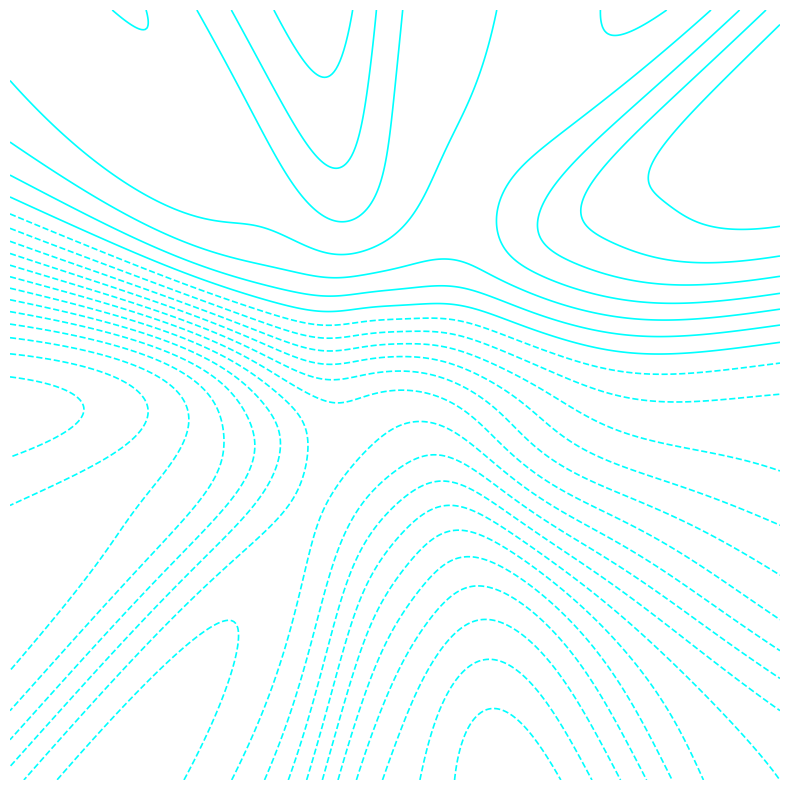

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------------------
# 1. Definir sigmoide o activación suave
# ----------------------------------------------------
def sigma(t):
    return 1 / (1 + np.exp(-t))

# ----------------------------------------------------
# 2. Red con UNA capa oculta (Cybenko-style)
#    G(x) = sum_j alpha_j * sigma(w_j^T x + b_j)
# ----------------------------------------------------
def build_network(hidden_dim=40, seed=0):
    rng = np.random.default_rng(seed)
    W = rng.normal(scale=5.0, size=(2, hidden_dim))   # pesos entrada→oculta
    b = rng.normal(scale=2.0, size=(hidden_dim,))     # sesgos capa oculta
    a = rng.normal(scale=2.0, size=(hidden_dim,))     # pesos ocultas→salida
    return W, b, a

def G(x, W, b, a):
    # x es (N,2)
    h = sigma(x @ W + b)   # (N,H)
    return h @ a           # (N,)

# ----------------------------------------------------
# 3. Generar malla en R^2 para visualizar G(x)
# ----------------------------------------------------
grid = 400
xs = np.linspace(-2, 2, grid)
ys = np.linspace(-2, 2, grid)
X, Y = np.meshgrid(xs, ys)
pts = np.stack([X.ravel(), Y.ravel()], axis=1)

# ----------------------------------------------------
# 4. Construir red (pesos aleatorios dan geometría rica)
# ----------------------------------------------------
W, b, a = build_network(hidden_dim=40, seed=42)
Z = G(pts, W, b, a).reshape(grid, grid)

# ----------------------------------------------------
# 5. Graficar curvas de nivel (estilo Mathelirium)
# ----------------------------------------------------
plt.figure(figsize=(8,8))
levels = np.linspace(Z.min(), Z.max(), 25)

plt.contour(X, Y, Z,
            levels=levels,
            colors='cyan',
            linewidths=1.2)

plt.gca().set_facecolor("black")
plt.axis('off')
plt.tight_layout()

plt.savefig("red_neuronal_contornos.png", dpi=300)
plt.show()

Epoch 300/1000000 - loss: 0.5717
Epoch 600/1000000 - loss: 0.5464
Epoch 900/1000000 - loss: 0.4712
Epoch 1200/1000000 - loss: 0.4110
Epoch 1500/1000000 - loss: 0.3498
Epoch 1800/1000000 - loss: 0.2931
Epoch 2100/1000000 - loss: 0.2324
Epoch 2400/1000000 - loss: 0.1948
Epoch 2700/1000000 - loss: 0.1664
Epoch 3000/1000000 - loss: 0.1445
Epoch 3300/1000000 - loss: 0.1406
Epoch 3600/1000000 - loss: 0.1208
Epoch 3900/1000000 - loss: 0.1126
Epoch 4200/1000000 - loss: 0.1074
Epoch 4500/1000000 - loss: 0.0925
Epoch 4800/1000000 - loss: 0.0978
Epoch 5100/1000000 - loss: 0.0956
Epoch 5400/1000000 - loss: 0.0875
Epoch 5700/1000000 - loss: 0.0845
Epoch 6000/1000000 - loss: 0.0886
Epoch 6300/1000000 - loss: 0.0722
Epoch 6600/1000000 - loss: 0.0794
Epoch 6900/1000000 - loss: 0.0743
Epoch 7200/1000000 - loss: 0.0819
Epoch 7500/1000000 - loss: 0.0796
Epoch 7800/1000000 - loss: 0.0734
Epoch 8100/1000000 - loss: 0.0703
Epoch 8400/1000000 - loss: 0.0651
Epoch 8700/1000000 - loss: 0.0699
Epoch 9000/100000

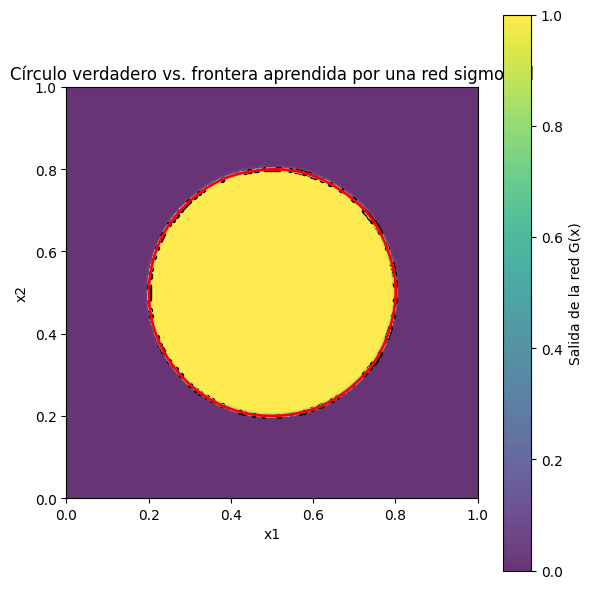

In [3]:
import numpy as np
import matplotlib.pyplot as plt


# ---------------------------------------------------------
# 1. Función verdadera: "estar dentro de un círculo"
#    Devuelve 1 si el punto está dentro, 0 si está fuera
# ---------------------------------------------------------
def true_region(x, center=(0.5, 0.5), radius=0.3):
    """
    x: array de forma (N, 2)
    center: centro del círculo
    radius: radio del círculo
    """
    center = np.asarray(center)
    d2 = np.sum((x - center) ** 2, axis=1)
    return (d2 <= radius ** 2).astype(float)


# ---------------------------------------------------------
# 2. Red neuronal 2 -> H -> 1 con sigmoide
#    G(x) = sum_j alpha_j * sigma(w_j^T x + b_j)
# ---------------------------------------------------------
class SimpleNN:
    def __init__(self, input_dim=2, hidden_dim=20, seed=0):
        rng = np.random.default_rng(seed)
        # pesos entrada -> oculta
        self.W1 = rng.normal(scale=1.0, size=(input_dim, hidden_dim))
        self.b1 = np.zeros(hidden_dim)
        # pesos oculta -> salida
        self.W2 = rng.normal(scale=1.0, size=(hidden_dim, 1))
        self.b2 = np.zeros(1)

    @staticmethod
    def sigmoid(z):
        return 1.0 / (1.0 + np.exp(-z))

    def forward(self, x):
        """
        x: (N, 2)
        devuelve:
            y_hat: (N, 1)  salida de la red
            h:     (N, H)  activaciones ocultas
        """
        z1 = x @ self.W1 + self.b1          # (N, H)
        h = self.sigmoid(z1)                # (N, H)
        z2 = h @ self.W2 + self.b2          # (N, 1)
        y_hat = self.sigmoid(z2)            # (N, 1)
        return y_hat, h

    def train(self, epochs=1500, batch_size=512, lr=0.5, radius=0.3):
        """
        Entrenamiento por descenso de gradiente (SGD) con entropía cruzada.
        """
        rng = np.random.default_rng(1)

        for epoch in range(epochs):
            # Muestras uniformes en el cuadrado [0,1]^2
            x = rng.random((batch_size, 2))
            y = true_region(x, radius=radius).reshape(-1, 1)

            # FORWARD
            y_hat, h = self.forward(x)

            # Gradiente de entropía cruzada + sigmoide: dL/dz2 = y_hat - y
            dz2 = (y_hat - y) / batch_size      # (N, 1)

            # Gradientes capa salida
            gW2 = h.T @ dz2                     # (H, 1)
            gb2 = dz2.sum(axis=0)               # (1,)

            # Backprop hacia capa oculta
            dh = dz2 @ self.W2.T                # (N, H)
            dz1 = dh * h * (1.0 - h)            # derivada sigmoide
            gW1 = x.T @ dz1                     # (2, H)
            gb1 = dz1.sum(axis=0)               # (H,)

            # Actualización
            self.W2 -= lr * gW2
            self.b2 -= lr * gb2
            self.W1 -= lr * gW1
            self.b1 -= lr * gb1

            # (Opcional) imprimir pérdida cada cierto tiempo
            if (epoch + 1) % 300 == 0:
                # pérdida binaria promedio
                eps = 1e-8
                loss = -np.mean(
                    y * np.log(y_hat + eps) + (1 - y) * np.log(1 - y_hat + eps)
                )
                print(f"Epoch {epoch+1}/{epochs} - loss: {loss:.4f}")


# ---------------------------------------------------------
# 3. Entrenar la red y visualizar la frontera de decisión
# ---------------------------------------------------------
if __name__ == "__main__":
    # Parámetros del círculo
    CENTER = (0.5, 0.5)
    RADIUS = 0.3

    # 3.1 Entrenar la red
    nn = SimpleNN(hidden_dim=30)
    nn.train(epochs=1000000, batch_size=1024, lr=0.5, radius=RADIUS)

    # 3.2 Evaluar en una rejilla fina del cuadrado [0,1]^2
    grid_size = 400
    xs = np.linspace(0.0, 1.0, grid_size)
    ys = np.linspace(0.0, 1.0, grid_size)
    Xg, Yg = np.meshgrid(xs, ys)
    grid_points = np.stack([Xg.ravel(), Yg.ravel()], axis=1)

    # Etiquetas verdaderas y predicciones de la red
    true_labels = true_region(grid_points, center=CENTER, radius=RADIUS)
    pred_probs, _ = nn.forward(grid_points)
    pred_probs = pred_probs.ravel()
    pred_labels = (pred_probs >= 0.5).astype(float)

    # Puntos mal clasificados
    misclassified = true_labels != pred_labels
    mc_points = grid_points[misclassified]

    # -----------------------------------------------------
    # 4. Gráfica:
    #    - Fondo: salida de la red G(x)
    #    - Contorno blanco: círculo verdadero
    #    - Contorno rojo: frontera de decisión de la red (G=0.5)
    #    - Puntos negros: errores de clasificación
    # -----------------------------------------------------
    fig, ax = plt.subplots(figsize=(6, 6))

    # Fondo: mapa de probabilidades predichas
    Z_pred = pred_probs.reshape(grid_size, grid_size)
    im = ax.imshow(
        Z_pred,
        origin="lower",
        extent=[0, 1, 0, 1],
        cmap="viridis",
        alpha=0.8,
    )

    # Frontera verdadera (círculo): contorno de la etiqueta real
    Z_true = true_labels.reshape(grid_size, grid_size)
    ax.contour(
        Xg,
        Yg,
        Z_true,
        levels=[0.5],
        colors="white",
        linewidths=2.0,
        linestyles="--",
    )

    # Frontera aprendida por la red: G(x) = 0.5
    ax.contour(
        Xg,
        Yg,
        Z_pred,
        levels=[0.5],
        colors="red",
        linewidths=2.0,
    )

    # Puntos mal clasificados
    if mc_points.size > 0:
        ax.scatter(mc_points[:, 0], mc_points[:, 1], s=8, c="black")

    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.set_title("Círculo verdadero vs. frontera aprendida por una red sigmoidal")

    plt.colorbar(im, ax=ax, label="Salida de la red G(x)")
    plt.tight_layout()
    plt.savefig("nn_circle_decision_boundary.png", dpi=300)
    plt.show()